In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
# All the first steps are exactly the same as we do in any ML case study.
# Also scaling is like a must in here because without this model wont perform well on the numeric inputs

In [4]:
# ── Load ─────────────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

print("Feature matrix shape:", X.shape)     # (569, 30)
print("Target shape:", y.shape)              # (569,)
print("Feature names (first 5):", data.feature_names[:5])
print("Class distribution:", np.bincount(y))  # [212, 357] — 0=malignant, 1=benign

# ── Split ────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale ────────────────────────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train) # Fit individually first then transform individually from this mold.

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Feature matrix shape: (569, 30)
Target shape: (569,)
Feature names (first 5): ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Class distribution: [212 357]


In [5]:
X_train.shape , y_train.shape

((455, 30), (455,))

In [6]:
# Create our Dataset class
# Basically we need to convert our dataset into a tensor , for which we pass the X and y values from respective set to the dunder method.
class BreastCancerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # shape (n,1) to match model output

    # Below functions are additional must have function (template) in any Dataset class
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Create the training set and testing set using our Custom Dataset class
train_dataset = BreastCancerDataset(X_train, y_train)
test_dataset = BreastCancerDataset(X_test, y_test)

# Pass them to loader with a batch_size to avoid overhead and using up all memory resources.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
train_dataset.__len__()

455

In [8]:
train_dataset.__getitem__(1) # Returns the first index

(tensor([ 1.7487,  0.0665,  1.7512,  1.7456,  1.2745,  0.8423,  1.5199,  1.9947,
         -0.2930, -0.3202,  0.1276, -0.3814,  0.0941,  0.3175,  0.6397,  0.0874,
          0.7085,  1.1822,  0.4262,  0.0748,  1.2283, -0.0928,  1.1875,  1.1044,
          1.5170,  0.2497,  1.1786,  1.5499,  0.1911, -0.1737]),
 tensor([0.]))

In [9]:
# If you try to run / print these objects above they will be shown as object from their class respectively 

In [10]:
# Now we trully make the architecture which we are going to use this model on the dataset 
# NOTE : We have 30 cols so input dim = 30
# For the activation function in hidden layers we go with relu
# #HIDDDEN layers = 2 ; to avoid dying relu
# Output layer activation function is sigmoid considering we have only two class to predict

In [11]:
# ── Classifier ────────────────────────────────────────────────────────────
class BreastCancerNet(nn.Module):
    def __init__(self, input_dim=30, dropout_rate=0.3):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, 10)
        self.layer2 = nn.Linear(10, 5)
        self.layer3 = nn.Linear(5, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)          # dropout after first hidden layer's activation
        x = self.relu(self.layer2(x))
        x = self.dropout(x)          # dropout after second hidden layer's activation
        x = self.sigmoid(self.layer3(x))
        return x

# Pass the model with X_train #columns 
model = BreastCancerNet(input_dim=X_train.shape[1])


print(model) # We get the model features fit 

BreastCancerNet(
  (layer1): Linear(in_features=30, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=5, bias=True)
  (layer3): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [12]:
# Sanity check for below code

# Pass on the batch size using an iterator object 
sample_X, sample_y = next(iter(train_loader))
print("Batch X shape:", sample_X.shape)   # expect (32, 30)
print("Batch y shape:", sample_y.shape)   # expect (32, 1)

output = model(sample_X)
print("Model output shape:", output.shape)  # expect (32, 1)

Batch X shape: torch.Size([32, 30])
Batch y shape: torch.Size([32, 1])
Model output shape: torch.Size([32, 1])


In [13]:
def train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs=50):
    # Dictionary to save performance metrics after every epoch for plotting later
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_accuracy": []
    }

    # Main loop repeating the entire training and testing cycle across epochs
    for epoch in range(n_epochs):
        
        # ── TRAINING PHASE ──────────────────────────────────────────
        model.train()             # Activate training-specific settings (e.g., dropout)
        running_train_loss = 0.0  # Clear and reset the training error scoreboard for this epoch

        # Automatically loop through the training dataset in randomized batches of 32
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()            # 1. Reset stored mathematical gradients from previous loops to zero
            y_pred = model(batch_X)          # 2. Forward pass: Feed batch features into model to get predictions
            loss = criterion(y_pred, batch_y)# 3. Compute error by comparing predictions to actual labels
            loss.backward()                  # 4. Backward pass: Trace error backwards to calculate gradients
            optimizer.step()                 # 5. Optimization step: Tweak model weights to decrease error
            
            running_train_loss += loss.item()# Convert single batch loss tensor to float and add to scoreboard

        # Calculate average training loss by dividing total error by number of batches processed
        avg_train_loss = running_train_loss / len(train_loader)

        # ── EVALUATION PHASE ─────────────────────────────────────────
        model.eval()             # Freeze specific layer dynamics to treat test data as a final exam
        running_test_loss = 0.0  # Reset the testing error scoreboard for this epoch
        correct = 0              # Reset counter for correctly predicted rows
        total = 0                # Reset counter for total test rows processed

        # Turn off gradient engine to save computing memory and speed up evaluation math
        with torch.no_grad():
            # Automatically loop through unseen evaluation data in batches
            for batch_X, batch_y in test_loader:
                y_pred = model(batch_X)          # Generate prediction probability scores for the test batch
                loss = criterion(y_pred, batch_y)# Calculate the evaluation batch error
                running_test_loss += loss.item() # Accumulate test error to scoreboard

                # Apply binary threshold: probabilities >= 0.5 become 1.0, others become 0.0
                predicted_labels = (y_pred >= 0.5).float()
                # Compare tensors, count matching True values, extract as a raw integer, and add to total
                correct += (predicted_labels == batch_y).sum().item()
                total += batch_y.size(0)         # Increment total row count by current batch size (e.g., 32)

        # Calculate finalized metric averages for the current epoch
        avg_test_loss = running_test_loss / len(test_loader)
        test_accuracy = correct / total

        # Save metrics into history dictionary tracking performance changes over time
        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_accuracy"].append(test_accuracy)

        # Print progress status report out to the screen every 5 epochs
        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, "
                  f"Test Loss = {avg_test_loss:.4f}, Test Accuracy = {test_accuracy:.4f}")

    return history


In [14]:
# Make a custom plotting function
def plot_history(history):
    epochs = range(len(history["train_loss"]))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Loss subplot
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="#2a78d6")
    axes[0].plot(epochs, history["test_loss"], label="Test Loss", color="#e34948")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Train vs Test Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy subplot
    axes[1].plot(epochs, history["test_accuracy"], label="Test Accuracy", color="#1baf7a")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Test Accuracy over Training")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch 0: Train Loss = 0.7176, Test Loss = 0.6920, Test Accuracy = 0.3684
Epoch 5: Train Loss = 0.5927, Test Loss = 0.5389, Test Accuracy = 0.8947
Epoch 10: Train Loss = 0.3771, Test Loss = 0.2980, Test Accuracy = 0.9386
Epoch 15: Train Loss = 0.2516, Test Loss = 0.1689, Test Accuracy = 0.9474
Epoch 20: Train Loss = 0.1905, Test Loss = 0.1265, Test Accuracy = 0.9561
Epoch 25: Train Loss = 0.1526, Test Loss = 0.1104, Test Accuracy = 0.9474
Epoch 30: Train Loss = 0.1412, Test Loss = 0.1013, Test Accuracy = 0.9474
Epoch 35: Train Loss = 0.1449, Test Loss = 0.0948, Test Accuracy = 0.9474
Epoch 40: Train Loss = 0.1162, Test Loss = 0.0912, Test Accuracy = 0.9561
Epoch 45: Train Loss = 0.1378, Test Loss = 0.0848, Test Accuracy = 0.9649


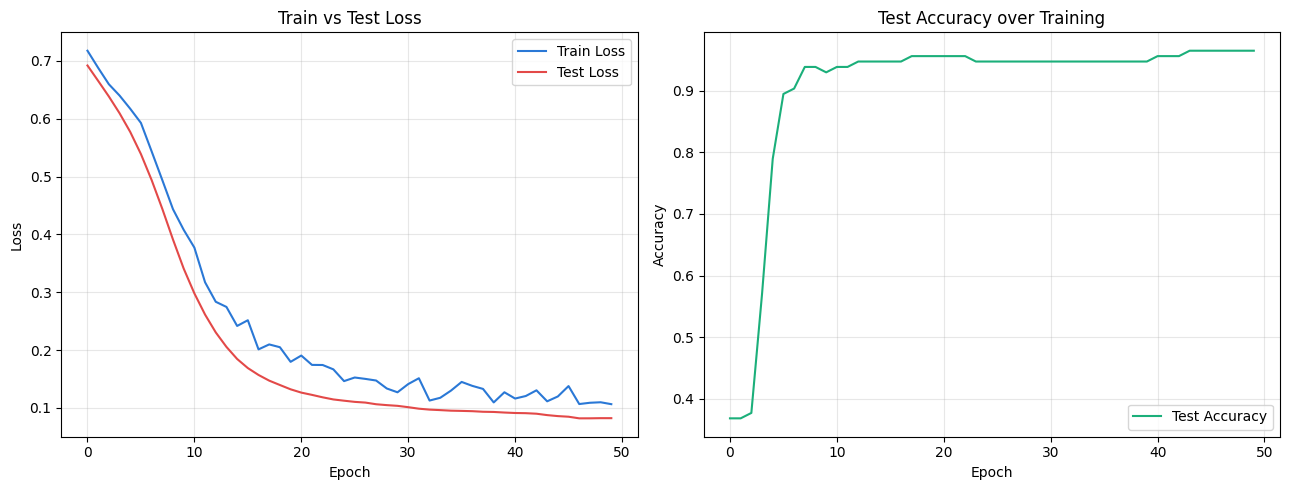

In [15]:
model = BreastCancerNet(input_dim=X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs=50)
plot_history(history)

In [ ]:
# The model was overfitting so we add Dropout for generalizing the node outputs.

#           Dropout prevents neurons from developing brittle, co-dependent relationships with specific other neurons (what's called co-adaptation), 
#   forcing each neuron to learn something individually useful. It's not that memorization stops entirely — 
#   it's that the specific mechanism by which overfitting happens (neurons ganging up on training-specific patterns together) gets disrupted.